# Ultramarathon Performance Visualizations — Part C
**Group 17 — Luiz Samelo, Maximilian Staudacher, Rayudu Muralikrishna**
*Information Visualization (VU 2.0), TU Wien, 2026*

- **Viz 5**: Age vs. speed scatter by gender
- **Viz 6**: Athlete career arc

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('../data/TWO_CENTURIES_OF_UM_RACES.csv')
print('Shape:', df.shape)
df.head()

Shape: (7461195, 13)


,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976,3
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469,4


In [4]:
df.columns = [
    'year', 'event_dates', 'race_name', 'race_length', 'num_finishers',
    'athlete_performance', 'athlete_club', 'athlete_country',
    'athlete_year_of_birth', 'athlete_gender', 'athlete_age_category',
    'athlete_avg_speed', 'athlete_id'
]
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['athlete_avg_speed'] = pd.to_numeric(df['athlete_avg_speed'], errors='coerce')
df['athlete_year_of_birth'] = pd.to_numeric(df['athlete_year_of_birth'], errors='coerce')
df['athlete_age'] = df['year'] - df['athlete_year_of_birth']

df_clean = df[
    (df['athlete_avg_speed'] > 0) & (df['athlete_avg_speed'] < 30) &
    (df['athlete_age'] >= 18) & (df['athlete_age'] <= 80) &
    (df['athlete_gender'].isin(['M', 'F'])) &
    (df['year'] >= 1970) & (df['year'] <= 2022)
    ].copy()
df_clean['Gender'] = df_clean['athlete_gender'].map({'M': 'Male', 'F': 'Female'})
df_clean['athlete_age'] = df_clean['athlete_age'].astype(int)
print('Cleaned shape:', df_clean.shape)

Cleaned shape: (6299362, 15)


## Viz 5 — Age vs Speed by Gender

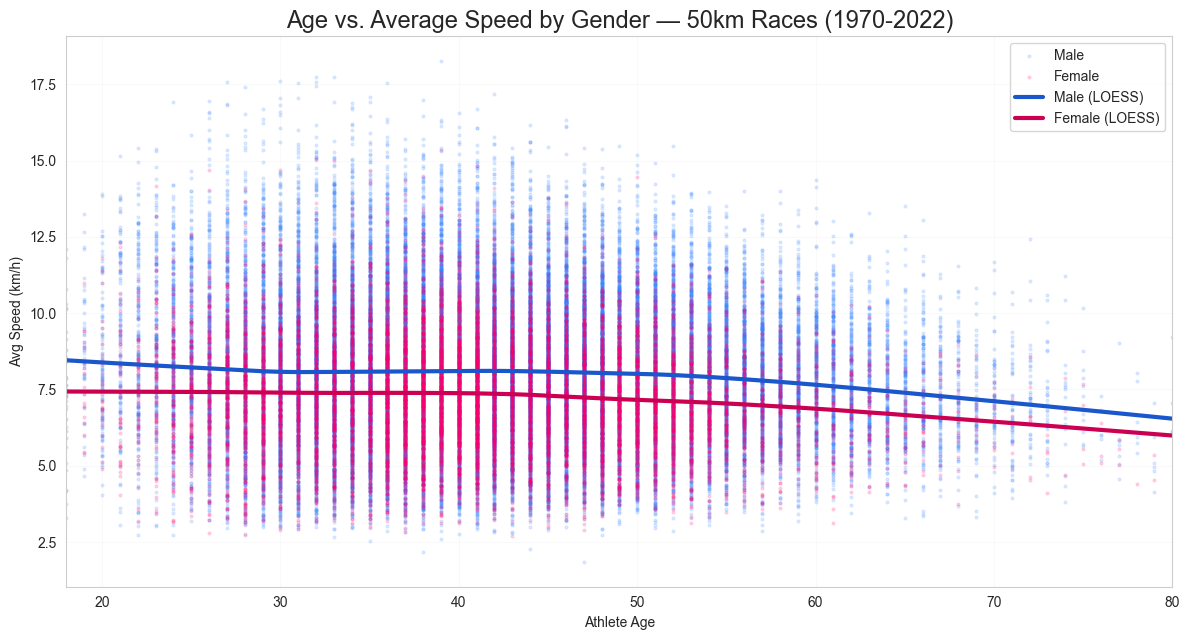

Saved viz5 PNG


In [5]:
df_50k = df_clean[df_clean['race_length'] == '50km'].copy()
df_scatter = df_50k.sample(n=min(50000, len(df_50k)), random_state=42).copy()

fig, ax = plt.subplots(figsize=(12, 6.5))

for gender, color in [('Male', '#3A86FF'), ('Female', '#FF006E')]:
    subset = df_scatter[df_scatter['Gender'] == gender]
    ax.scatter(subset['athlete_age'], subset['athlete_avg_speed'],
               color=color, alpha=0.15, s=4, label=gender)

for gender, color in [('Male', '#1a56cc'), ('Female', '#cc0052')]:
    subset = df_50k[df_50k['Gender'] == gender].dropna(subset=['athlete_age', 'athlete_avg_speed'])
    smoothed = lowess(subset['athlete_avg_speed'], subset['athlete_age'], frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color=color, linewidth=3, label=f'{gender} (LOESS)')

ax.set_xlim(18, 80)
ax.set_xlabel('Athlete Age')
ax.set_ylabel('Avg Speed (km/h)')
ax.set_title('Age vs. Average Speed by Gender — 50km Races (1970-2022)', fontsize=17)
ax.grid(True, color='#f0f0f0')
ax.legend()
plt.tight_layout()
plt.savefig('../Viz/viz5_age_vs_speed_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz5 PNG')

## Viz 6 — Athlete Career Arc

In [12]:
df_50k = df_clean[df_clean['race_length'] == '50km'].copy()

athlete_counts_50k = (
    df_50k.groupby('athlete_id')
    .agg(race_count=('year', 'count'), career_span=('year', lambda x: x.max() - x.min()))
    .reset_index()
)
qualified_ids = athlete_counts_50k[
    (athlete_counts_50k['race_count'] >= 5) &
    (athlete_counts_50k['career_span'] >= 3)
    ]['athlete_id'].tolist()
print(f"Qualified athletes: {len(qualified_ids)}")

career_data = (
    df_50k[df_50k['athlete_id'].isin(qualified_ids)]
    .groupby(['athlete_id', 'year'])
    .agg(avg_speed=('athlete_avg_speed', 'mean'), age=('athlete_age', 'mean'))
    .reset_index()
)
career_data['avg_speed'] = career_data['avg_speed'].round(2)
career_data['first_year'] = career_data.groupby('athlete_id')['year'].transform('min')
career_data['career_year'] = career_data['year'] - career_data['first_year']

athlete_stats = []
for aid, grp in career_data.groupby('athlete_id'):
    grp = grp.sort_values('career_year')
    speeds = grp['avg_speed'].values
    years = grp['career_year'].values
    if len(grp) < 3:
        continue
    mid = years[-1] / 2
    fh = speeds[years <= mid].mean()
    sh = speeds[years > mid].mean() if (years > mid).any() else np.nan
    slope = np.polyfit(years, speeds, 1)[0]
    athlete_stats.append({
        'athlete_id': aid,
        'career_span': years[-1],
        'n_years': len(grp),
        'slope': slope,
        'peak_frac': years[speeds.argmax()] / max(years[-1], 1),
        'cv': np.std(speeds) / np.mean(speeds),
        'speed_change_pct': (sh - fh) / fh if fh and not np.isnan(sh) else np.nan,
        'mid_dip': speeds[len(speeds) // 4: 3 * len(speeds) // 4].min() - speeds[:len(speeds) // 4].mean(),
    })
stats_df = pd.DataFrame(athlete_stats)

MIN_SPAN, MIN_YEARS = 8, 7
selected = {}

# Early Peaker
cands = stats_df[
    (stats_df['career_span'] >= MIN_SPAN) & (stats_df['n_years'] >= MIN_YEARS) &
    (stats_df['peak_frac'] <= 0.30) & (stats_df['speed_change_pct'] < -0.05)
    ]
if len(cands):
    selected['Early Peaker'] = cands.nlargest(1, 'career_span')['athlete_id'].iloc[0]

# Late Bloomer
cands = stats_df[
    (stats_df['career_span'] >= MIN_SPAN) & (stats_df['n_years'] >= MIN_YEARS) &
    (stats_df['slope'] > 0) & (stats_df['speed_change_pct'] > 0.10)
    ]
cands = cands[~cands['athlete_id'].isin(selected.values())]
if len(cands):
    selected['Late Bloomer'] = cands.nlargest(1, 'slope')['athlete_id'].iloc[0]

# Consistent
cands = stats_df[
    (stats_df['career_span'] >= MIN_SPAN) & (stats_df['n_years'] >= MIN_YEARS)
    ]
cands = cands[~cands['athlete_id'].isin(selected.values())]
if len(cands):
    selected['Consistent'] = cands.nsmallest(1, 'cv')['athlete_id'].iloc[0]

# Comeback
cands = stats_df[
    (stats_df['career_span'] >= MIN_SPAN) & (stats_df['n_years'] >= MIN_YEARS) &
    (stats_df['mid_dip'] < -0.5)
    ]
cands = cands[~cands['athlete_id'].isin(selected.values())]
if len(cands):
    selected['Comeback'] = cands.nsmallest(1, 'mid_dip')['athlete_id'].iloc[0]

print("\nNotable athletes:")
for archetype, aid in selected.items():
    row = stats_df[stats_df['athlete_id'] == aid].iloc[0]
    print(f"  {archetype}: ID={aid}, span={row['career_span']:.0f}yr, n_years={row['n_years']:.0f}, "
          f"slope={row['slope']:.3f}, change={row['speed_change_pct']:.1%}, cv={row['cv']:.3f}")

Qualified athletes: 60088

Notable athletes:
  Early Peaker: ID=405, span=26yr, n_years=15, slope=-0.257, change=-35.8%, cv=0.242
  Late Bloomer: ID=227545, span=8yr, n_years=7, slope=0.820, change=59.0%, cv=0.292
  Consistent: ID=1159822, span=8yr, n_years=7, slope=0.017, change=0.9%, cv=0.008
  Comeback: ID=203387, span=26yr, n_years=9, slope=-0.289, change=-39.9%, cv=0.333


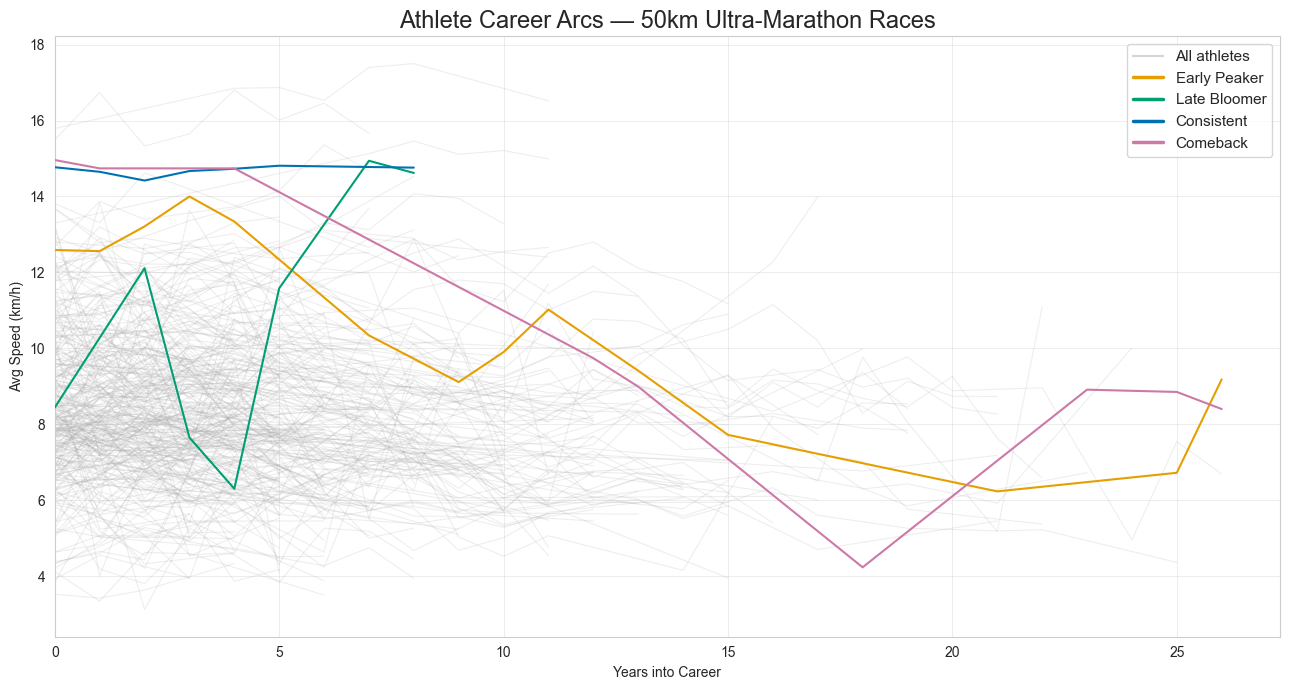

Saved viz6 PNG


In [19]:
COLORS = {
    'Early Peaker': '#E69F00',
    'Late Bloomer': '#009E73',
    'Consistent': '#0072B2',
    'Comeback': '#CC79A7',
}

fig, ax = plt.subplots(figsize=(13, 7))

np.random.seed(42)
bg_ids = np.random.choice(
    [aid for aid in career_data['athlete_id'].unique() if aid not in selected.values()],
    size=min(300, career_data['athlete_id'].nunique()),
    replace=False
)
bg_data = career_data[career_data['athlete_id'].isin(bg_ids)]

for _, grp in bg_data.groupby('athlete_id'):
    grp = grp.sort_values('career_year')
    ax.plot(grp['career_year'], grp['avg_speed'],
            color='#aaaaaa', alpha=0.2, linewidth=0.8, zorder=1)

for archetype, aid in selected.items():
    grp = career_data[career_data['athlete_id'] == aid].sort_values('career_year')
    ax.plot(grp['career_year'], grp['avg_speed'],
            color=COLORS[archetype], linewidth=1.5, zorder=3, label=archetype)

legend_handles = (
        [Line2D([0], [0], color='#aaaaaa', linewidth=1.5, alpha=0.5, label='All athletes')] +
        [Line2D([0], [0], color=COLORS[a], linewidth=2.5, label=a) for a in selected]
)
ax.legend(handles=legend_handles, fontsize=11)
ax.set_xlabel('Years into Career')
ax.set_ylabel('Avg Speed (km/h)')
ax.set_title('Athlete Career Arcs — 50km Ultra-Marathon Races', fontsize=17)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig('../Viz/viz6_athlete_career_arc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz6 PNG')